In [29]:
# Importing Pandas, and checking the kernel
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

print(sys.executable)

/home/aviraljoshi/mini-logistic-regression/.venv/bin/python3


In [2]:
pd.read_csv?

Signature:
pd.read_csv(
    filepath_or_buffer: 'FilePath | ReadCsvBuffer[bytes] | ReadCsvBuffer[str]',
    *,
    sep: 'str | None | lib.NoDefault' = <no_default>,
    delimiter: 'str | None | lib.NoDefault' = None,
    header: "int | Sequence[int] | None | Literal['infer']" = 'infer',
    names: 'Sequence[Hashable] | None | lib.NoDefault' = <no_default>,
    index_col: 'IndexLabel | Literal[False] | None' = None,
    usecols: 'UsecolsArgType' = None,
    dtype: 'DtypeArg | None' = None,
    engine: 'CSVEngine | None' = None,
    converters: 'Mapping[HashableT, Callable] | None' = None,
    true_values: 'list | None' = None,
    false_values: 'list | None' = None,
    skipinitialspace: 'bool' = False,
    skiprows: 'list[int] | int | Callable[[Hashable], bool] | None' = None,
    skipfooter: 'int' = 0,
    nrows: 'int | None' = None,
    na_values: 'Hashable | Iterable[Hashable] | Mapping[Hashable, Iterable[Hashable]] | None' = None,
    keep_default_na: 'bool' = True,
    na_filter: 

In [3]:
# Loading the dataset
from sklearn.datasets import load_breast_cancer

bunch = load_breast_cancer(as_frame=True)
df = bunch.frame

print(type(bunch))
print(type(df))
print(df.shape)

<class 'sklearn.utils._bunch.Bunch'>
<class 'pandas.DataFrame'>
(569, 31)


In [4]:
bunch.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [5]:
print(bunch.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [6]:
print(bunch.target_names)

['malignant' 'benign']


## Which class is `0` and which is `1`?

In this dataset:

| Label | Meaning |
|---:|---|
| `0` | Malignant — cancer |
| `1` | Benign — not cancer |

This is somewhat **counterintuitive**.

In many machine-learning and medical contexts, the **positive class (`1`)** usually represents the condition or event we're looking for.

For a cancer-detection problem, we would normally expect:

```text
1 → Malignant (cancer)
0 → Benign (not cancer)

In [7]:
# Flipping the target so 1 = malignant
df['target'] = 1 - df['target']
print(df['target'].value_counts())

target
0    357
1    212
Name: count, dtype: int64


In [8]:
current_directory = Path.cwd()
print(current_directory)

/home/aviraljoshi/mini-logistic-regression/notebooks


In [9]:
root_directory = current_directory.parent
print(root_directory)

/home/aviraljoshi/mini-logistic-regression


In [10]:
data_folder_path = root_directory/"data"
print(data_folder_path)

/home/aviraljoshi/mini-logistic-regression/data


In [11]:
df.to_csv(data_folder_path/"breast_cancer.csv", index=False) # mode="x" if you donot want to overwrite

In [12]:
df= pd.read_csv(data_folder_path/"breast_cancer.csv")
print(df.shape)
print(df['target'].value_counts())

(569, 31)
target
0    357
1    212
Name: count, dtype: int64


In [13]:
pd.set_option("display.max_columns", None)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [14]:
df.head().T

,0,1,2,3,4
mean radius,17.990000,20.570000,19.690000,11.420000,20.290000
mean texture,10.380000,17.770000,21.250000,20.380000,14.340000
mean perimeter,122.800000,132.900000,130.000000,77.580000,135.100000
mean area,1001.000000,1326.000000,1203.000000,386.100000,1297.000000
mean smoothness,0.118400,0.084740,0.109600,0.142500,0.100300
mean compactness,0.277600,0.078640,0.159900,0.283900,0.132800
mean concavity,0.300100,0.086900,0.197400,0.241400,0.198000
mean concave points,0.147100,0.070170,0.127900,0.105200,0.104300
mean symmetry,0.241900,0.181200,0.206900,0.259700,0.180900
mean fractal dimension,0.078710,0.056670,0.059990,0.097440,0.058830


In [15]:
# Checking column types with 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [16]:
# missing-value check
missing_per_column = df.isna().sum()
print(missing_per_column)
print(f"Total missing values in the table {missing_per_column.sum()}")

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64
Total missing values in the table 0


In [17]:
df.isna().equals(df.isnull())

True

## What we'd do if these checks had failed

But what to do when a check *fails*.

### 1. Missing values (`NaN`)

- **Few rows affected:** Drop them with `df.dropna()`. We lose a little data, but don't make anything up.
- **Many values affected:** **Impute** (fill) the missing values instead, e.g. with the column's **median** using `df.fillna(...)`.

> **Important:** Calculate the median using **training data only**. Using the full dataset causes **data leakage**.

### 2. Wrong column dtype

A numeric column may appear as `object` because some cells contain text like `"?"`, `"n/a"`, or `"1,234"`.

- **Fix:** `pd.to_numeric(df["col"], errors="coerce")`
- `errors="coerce"` converts values that can't be parsed into `NaN`.
- Then handle those `NaN` values using the approach above.

### Key idea

**Missing values → drop or impute.**  
**Wrong dtype → convert to numeric → invalid values become `NaN` → handle them.**

In [18]:
# Summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## What to look for in `df.describe()`

You don't need to read every number. **Scan for four specific things:**

1. **Impossible values** → Check `min` and `max` to see if the values are realistic.
   - Example: a negative radius would indicate a possible data error.

2. **Mean vs median** → Compare `mean` with `50%` (median) to spot **skew**.
   - If the mean is much higher/lower than the median, some extreme values may be pulling it.

3. **Different scales** → Check whether columns have very different ranges.
   - Large differences in scale can affect gradient descent, so we'll need **feature scaling** before training.

4. **Target distribution** → Check the `target` row to understand **class balance**.
   - For a `0/1` target, the mean equals the fraction of samples belonging to class `1`.
   - Here, `mean ≈ 0.373` → about **37% of samples are class `1`**.

> **Mental checklist:**  
> **Impossible values → Skew → Scale → Class balance**

In [19]:
# Splitting features (X) from target (y)

X_df = df.drop(columns = "target")
y = df["target"]

print(X_df.shape)
print(y.shape)

(569, 30)
(569,)


In [20]:
# Switch Pandas → NumPy
X = X_df.to_numpy()
y_arr = y.to_numpy()

print(type(X), X.shape, X.dtype)
print(type(y_arr), y_arr.shape, y_arr.dtype)

<class 'numpy.ndarray'> (569, 30) float64
<class 'numpy.ndarray'> (569,) int64


## Matplotlib: Figure vs Axes

Matplotlib plots are mainly built from two objects:

### 1. Figure → the whole canvas

The **Figure** is the entire image or canvas.

- Controls the overall size of the plot.
- Can contain one or more plots.
- Is what gets displayed or saved as an image.
- Does not directly draw the data.

Think: **Figure = blank sheet of paper**

### 2. Axes → one plot inside the canvas

An **Axes** is a single plot area.

It contains:

- x-axis and y-axis
- title
- axis labels
- data (points, lines, bars, etc.)

**All actual plotting happens on an Axes.**

Think: **Axes = one individual chart on the paper**

### One Figure can contain multiple Axes

For example, two plots side by side:

    ┌──────────── Figure ────────────┐
    │ ┌── Axes 1 ──┐  ┌── Axes 2 ──┐ │
    │ │   plot     │  │   plot     │ │
    │ └────────────┘  └────────────┘ │
    └────────────────────────────────┘

### ⚠️ Naming trap

- **Axes** (with `e`) → one complete plot area.
- **axis** → one line inside an Axes, such as the x-axis or y-axis.

So:

**1 Figure → many Axes → each Axes has x-axis + y-axis**

### Typical workflow

1. Create a **Figure** with the Axes you need.
2. Draw data onto an **Axes**.
3. Add title and labels to that **Axes**.
4. Show or save the **Figure**.

> **Remember:**  
> **Figure = canvas**  
> **Axes = actual plot**

<class 'tuple'>
<class 'matplotlib.figure.Figure'>
<class 'matplotlib.axes._axes.Axes'>


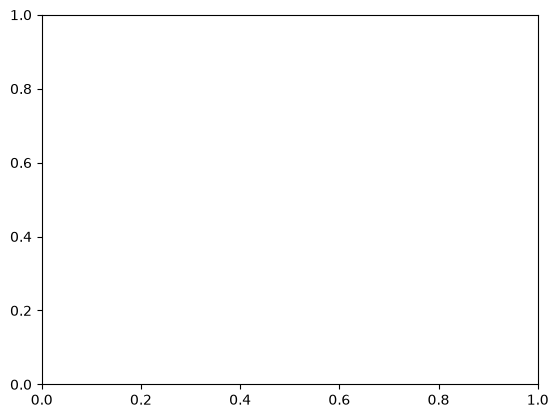

In [23]:
result = plt.subplots()
print(type(result))

fig, ax = result
print(type(fig))
print(type(ax))

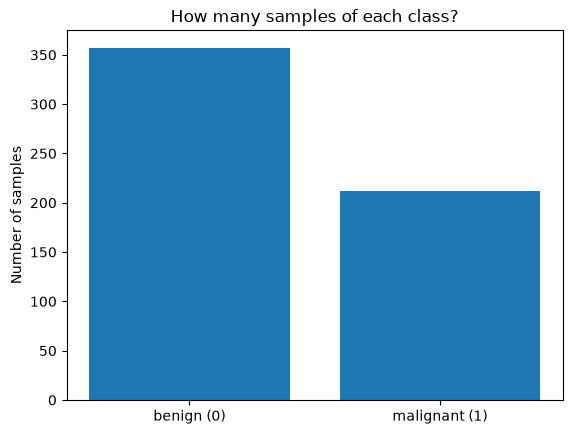

In [27]:
# First plot, class balance

counts = df['target'].value_counts().sort_index()

fig, ax = plt.subplots()
ax.bar(["benign (0)", "malignant (1)"], counts.to_numpy())
ax.set_title("How many samples of each class?")
ax.set_ylabel("Number of samples")
plt.show()

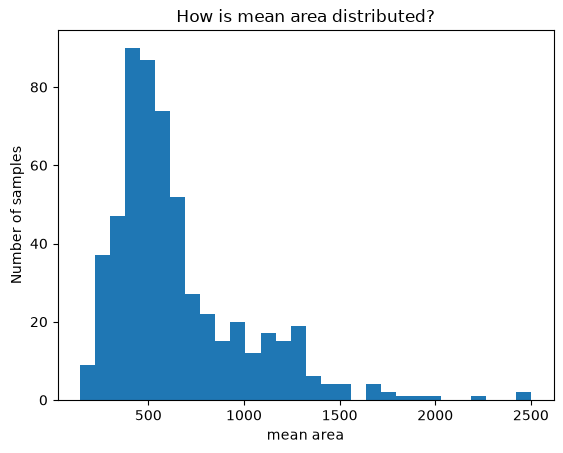

In [28]:
fig, ax = plt.subplots()
ax.hist(df["mean area"], bins= 30)
ax.set_title("How is mean area distributed?")
ax.set_xlabel("mean area")
ax.set_ylabel("Number of samples")
plt.show()

- **Shows that the data is right skewed**

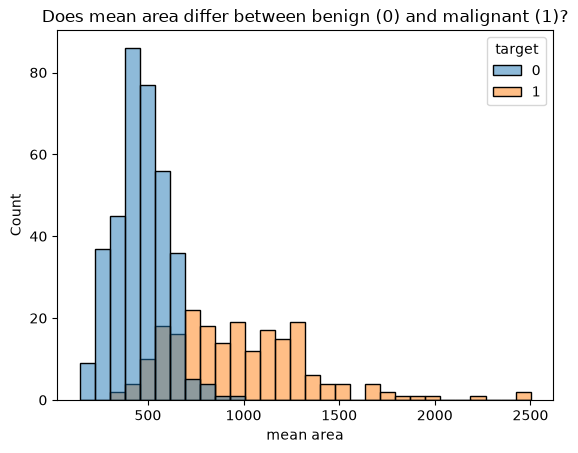

In [30]:
fig, ax = plt.subplots()
sns.histplot(data=df, x="mean area", hue="target", bins=30, ax= ax)
ax.set_title("Does mean area differ between benign (0) and malignant (1)?")
plt.show()

- **Larger area strongly suggests malignant**, so `area` is likely to be an important feature for the model.
- There is still an **overlap zone** (roughly `600–900`) where both classes appear.
- Therefore, **area alone cannot perfectly separate the two classes**.
- The model will need to combine `area` with **other features** to make better predictions.

> **Key idea:** A useful feature does not have to perfectly separate the classes. It can still provide valuable information when combined with other features.

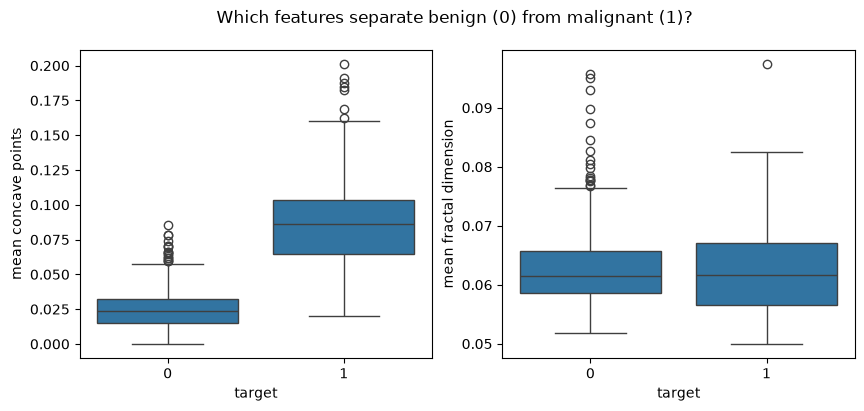

In [31]:
# Boxplot
fig, (ax1, ax2) = plt.subplots(1,2, figsize= (10, 4))
sns.boxplot(data= df, x = "target", y = "mean concave points", ax= ax1)
sns.boxplot(data = df, x = "target", y = "mean fractal dimension", ax= ax2)
fig.suptitle("Which features separate benign (0) from malignant (1)?")
plt.show()

- **`mean concave points`** is a **strong separator** → its value gives us a lot of information about the class.
- **`mean fractal dimension`** is a **weak separator** → by itself, it provides very little information for distinguishing the classes.

> **Key idea:** Some features are much more useful than others for separating classes.